<a href="https://colab.research.google.com/github/Amanmandal5/jansetu-ai-civic-care/blob/main/wineprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# **Upload Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

# **Load Dataset**

In [ ]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1143, 13)


# **First 5 Records**

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# **Last 5 Records**

In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


# **Random Records**

In [ ]:
df.sample(5, random_state=42)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
158,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,5,222
1081,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,6,1514
291,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,5,417
538,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,6,754
367,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,6,516


# **Dataset Information**

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of Rows: 1143
Number of Columns: 13

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


# **Unique Values**

In [ ]:
unique_values = df.nunique()

print(unique_values)

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64


# **Missing Values**

In [ ]:
print("Missing values in each column:\n")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values: 0


# **Duplicate Records**

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


# **Statistical Summary**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


# **Quality Distribution**

In [ ]:
print("Wine Quality Distribution:")
print(df['quality'].value_counts().sort_index())

Wine Quality Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


# **Quality Distribution Graph**

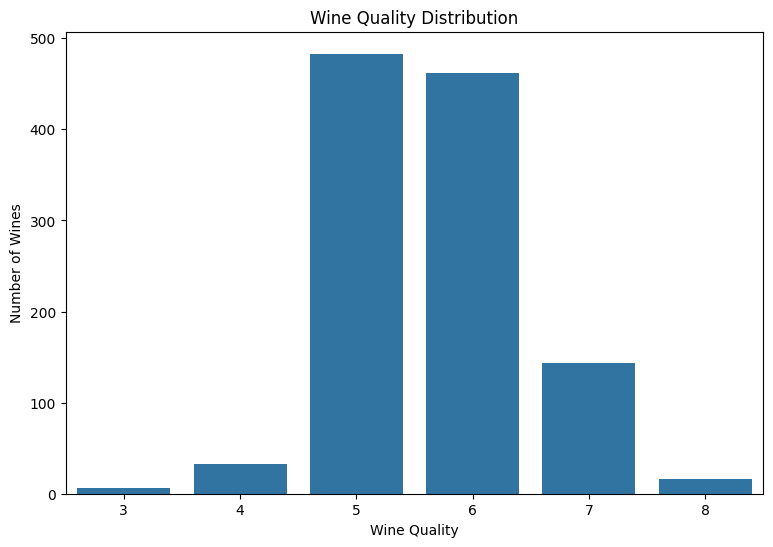

In [ ]:

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='quality',
    order=sorted(df['quality'].unique())
)

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.show()

# **Most & Least Common Quality**

In [ ]:
quality_counts = df['quality'].value_counts()

most_common = quality_counts.idxmax()
least_common = quality_counts.idxmin()

print("Most common quality:", most_common)
print("Number of wines:", quality_counts.max())

print("\nLeast common quality:", least_common)
print("Number of wines:", quality_counts.min())

Most common quality: 5
Number of wines: 483

Least common quality: 3
Number of wines: 6


# **Feature Histograms**

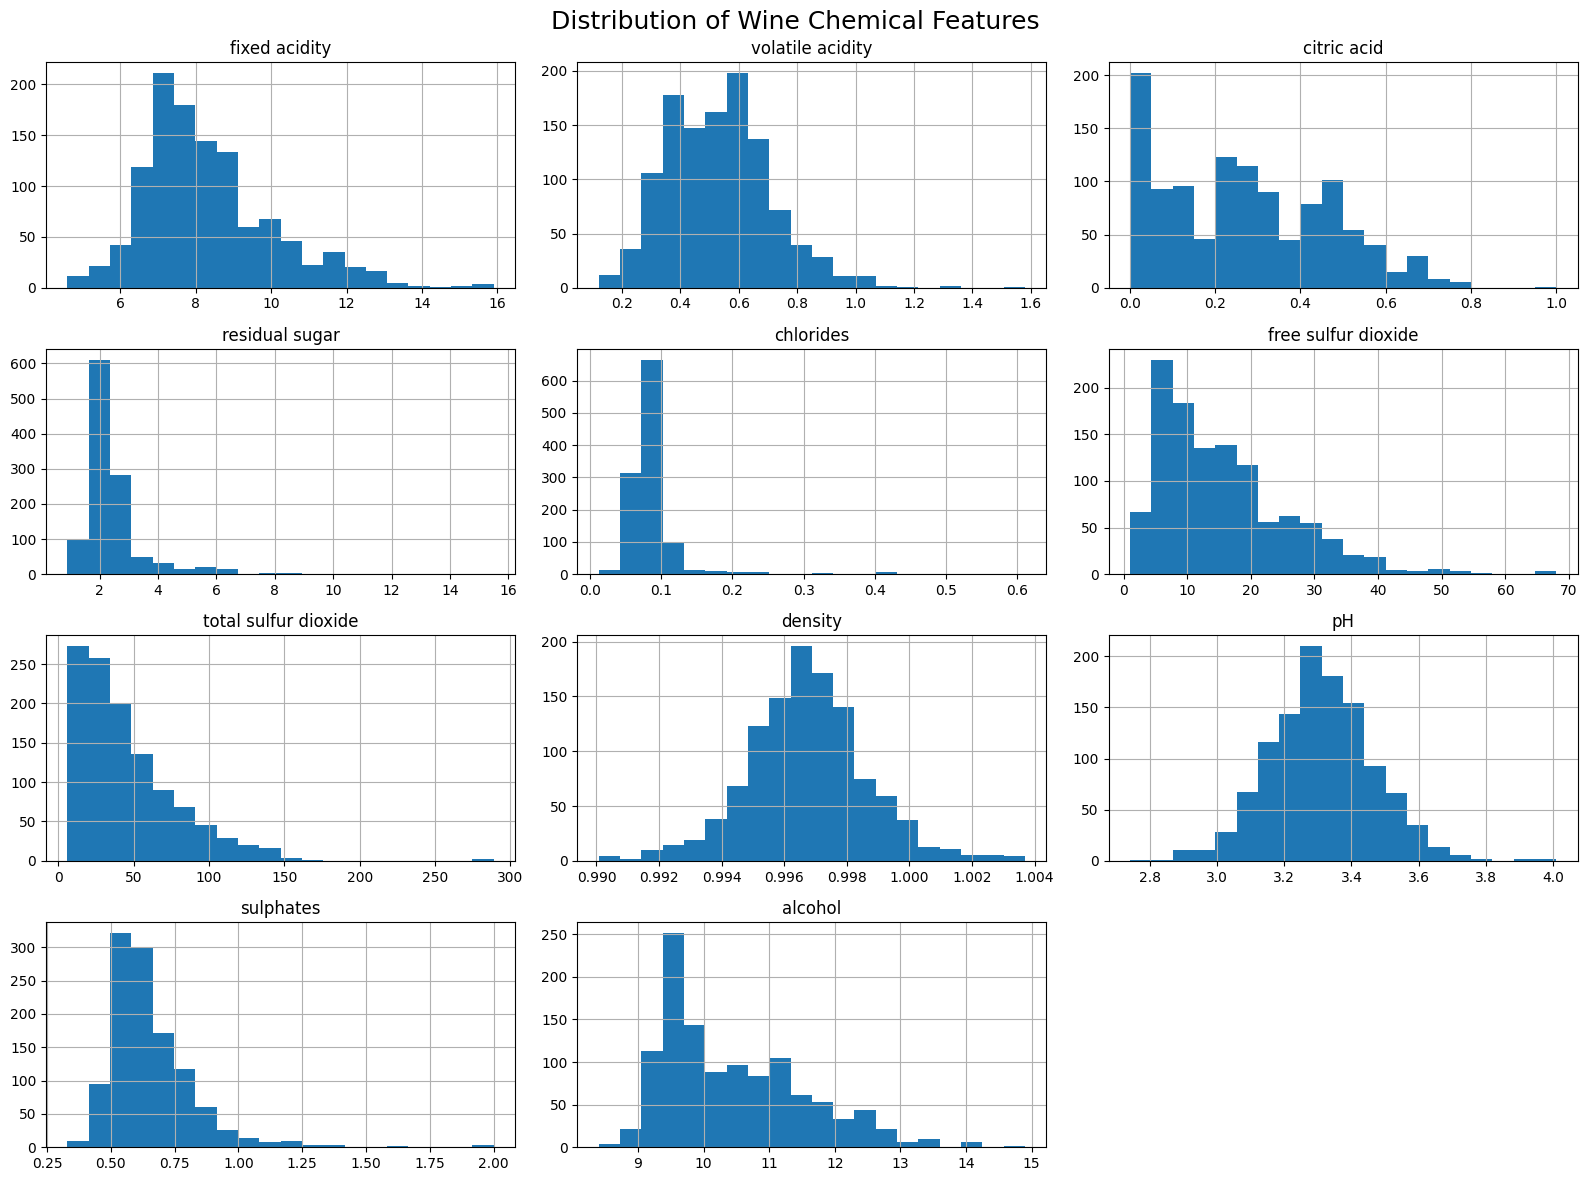

In [ ]:
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

df[features].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle("Distribution of Wine Chemical Features", fontsize=18)

plt.tight_layout()
plt.show()

# **Alcohol vs Quality**

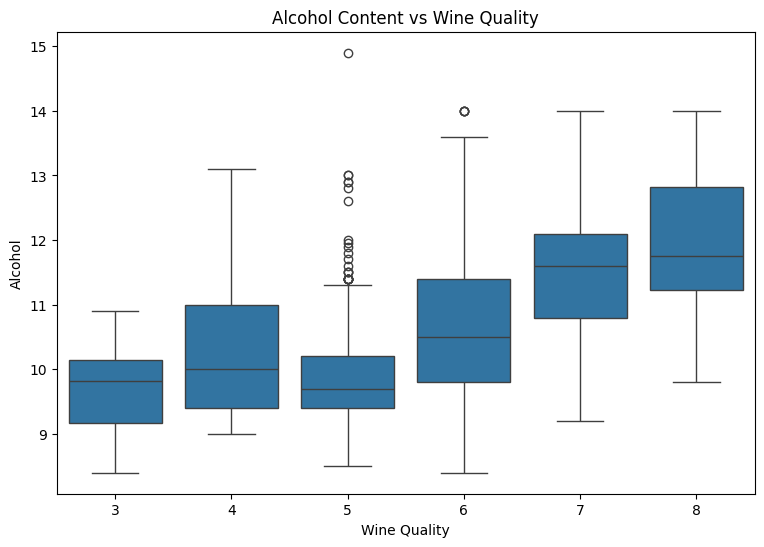

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='quality',
    y='alcohol'
)

plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")

plt.show()

# **Volatile Acidity vs Quality**

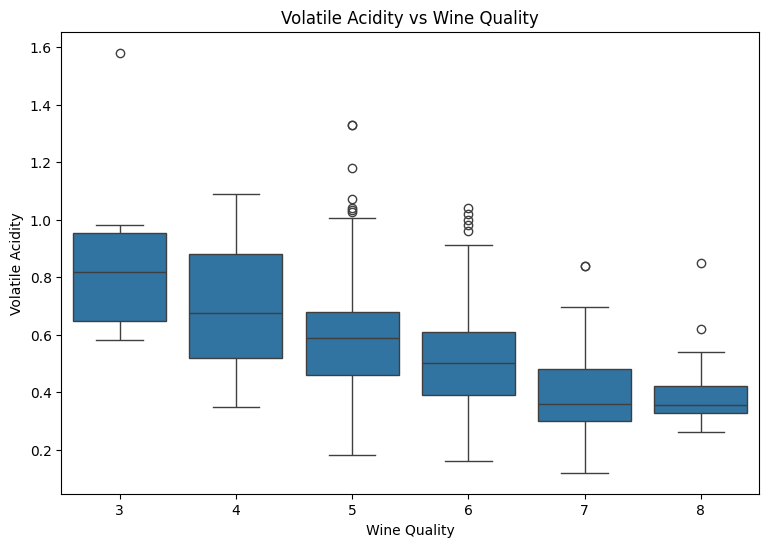

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='quality',
    y='volatile acidity'
)

plt.title("Volatile Acidity vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Volatile Acidity")

plt.show()

# **Sulphates vs Quality**

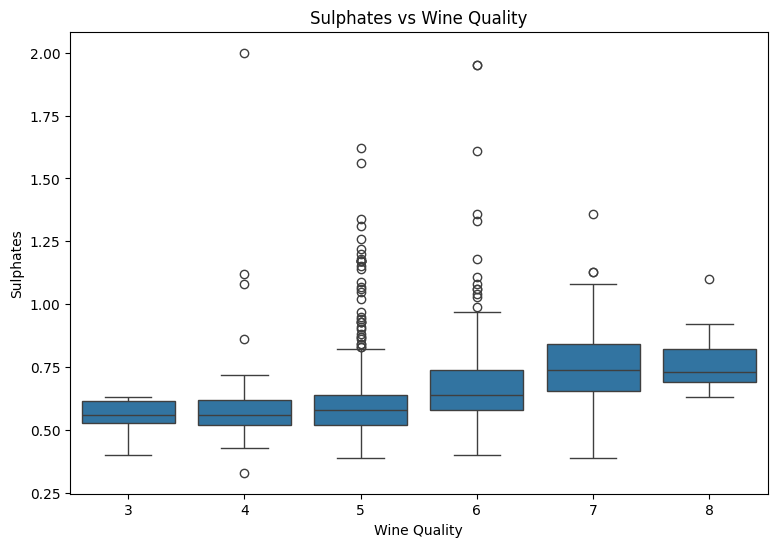

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='quality',
    y='sulphates'
)

plt.title("Sulphates vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Sulphates")

plt.show()

# **pH vs Quality**

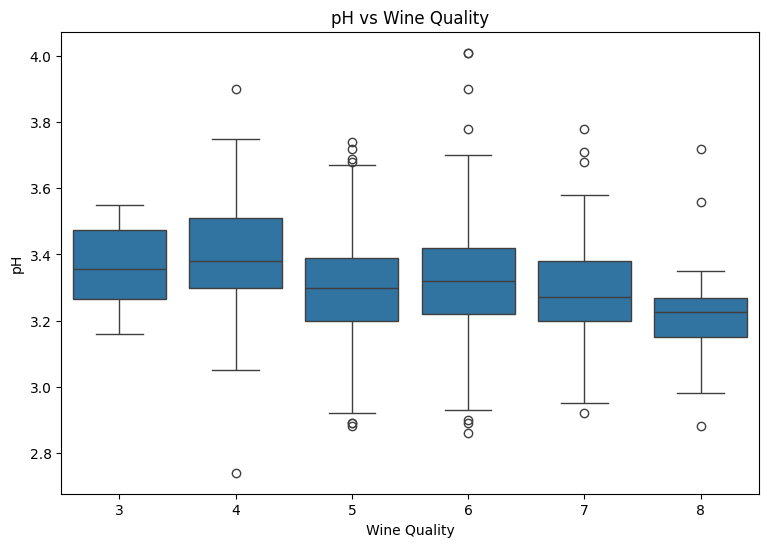

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='quality',
    y='pH'
)

plt.title("pH vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("pH")

plt.show()

# **Citric Acid vs Quality**

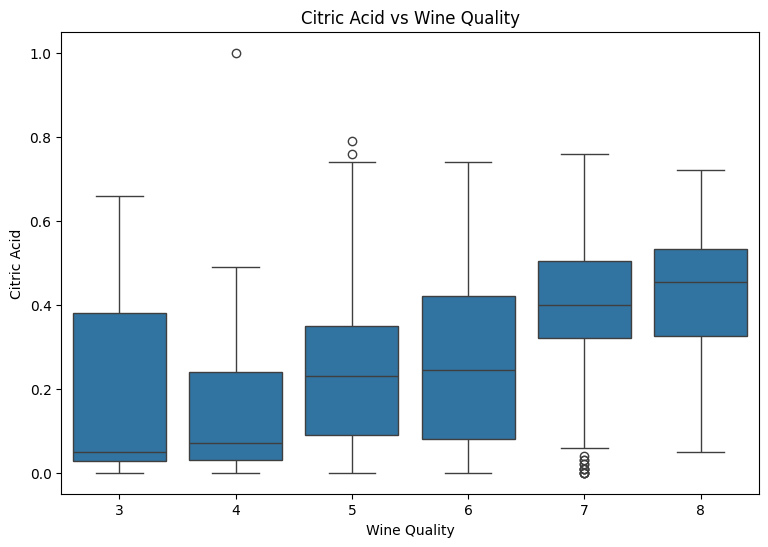

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='quality',
    y='citric acid'
)

plt.title("Citric Acid vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Citric Acid")

plt.show()

# **Outlier Detection**

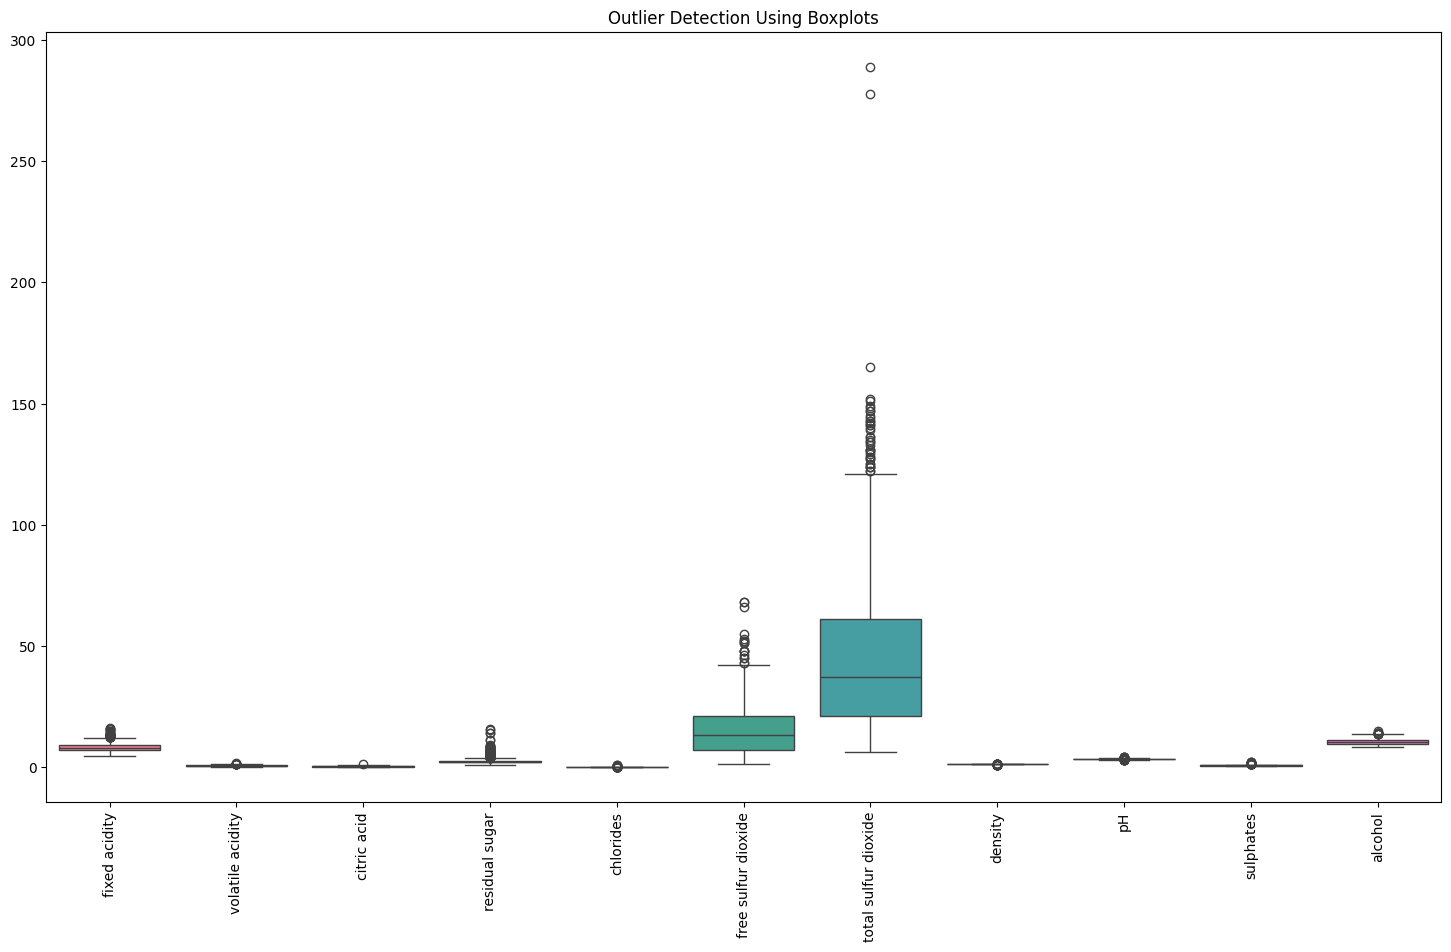

In [ ]:
plt.figure(figsize=(18, 10))

sns.boxplot(data=df[features])

plt.xticks(rotation=90)

plt.title("Outlier Detection Using Boxplots")

plt.show()

# **Correlation Matrix**

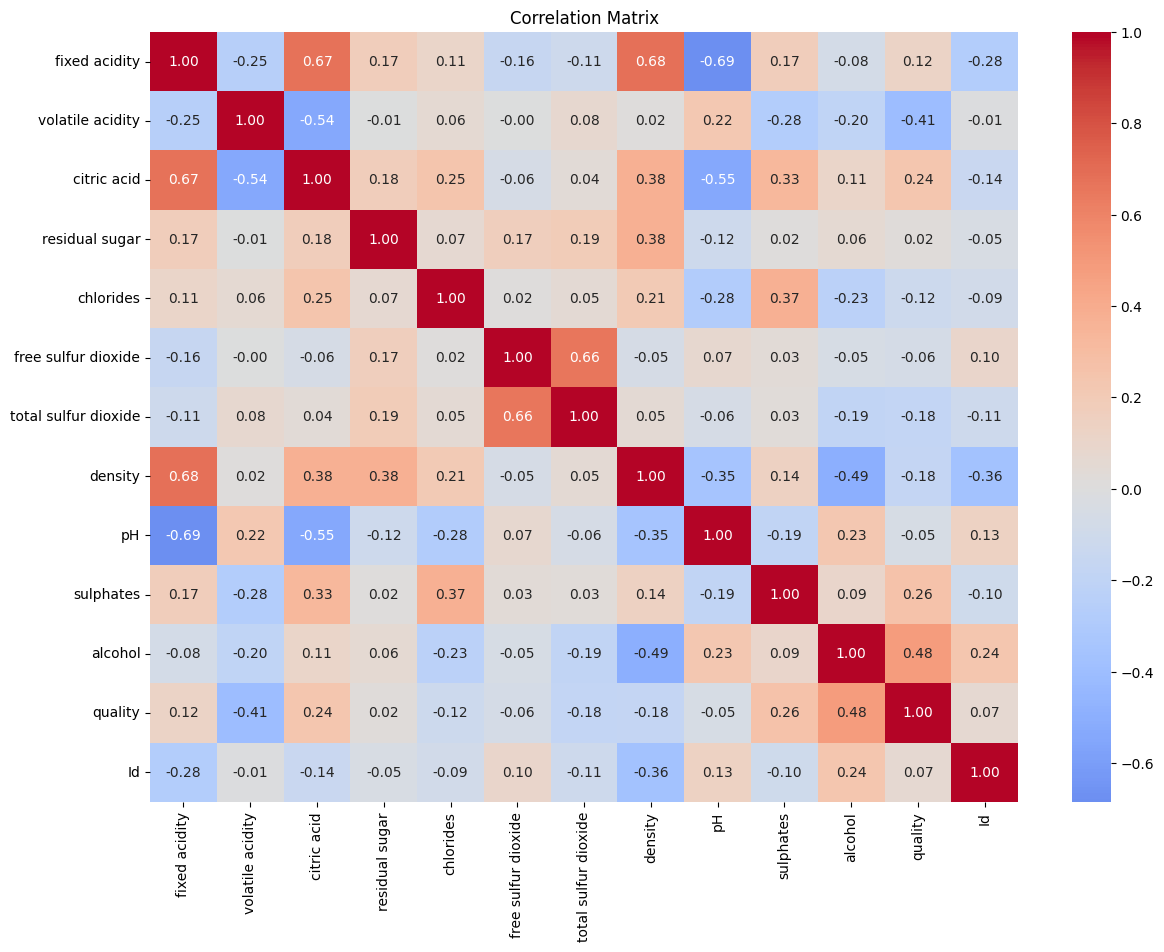

In [ ]:

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# **Correlation With Quality**

In [ ]:
quality_corr = correlation['quality'].sort_values(
    ascending=False
)

print("Correlation with Wine Quality:\n")
print(quality_corr)

Correlation with Wine Quality:

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


# **Prepare X and y**

In [ ]:
X = df.drop(
    columns=['quality', 'Id']
)

y = df['quality']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget:")
print("quality")

X shape: (1143, 11)
y shape: (1143,)

Input Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality


# **Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 914
Testing samples: 229


# **Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


# **Logistic Regression**

In [ ]:
logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


# **Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


# **Support Vector Machine**

In [ ]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM trained successfully!")

SVM trained successfully!


# **KNN**

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN trained successfully!")

KNN trained successfully!


# **Model Evaluation Function**

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# **Compare All Models**

In [ ]:

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        svm_pred
    )
)

results.append(
    evaluate_model(
        "KNN",
        y_test,
        knn_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.624454,0.587715,0.624454,0.603652
1,Random Forest,0.685590,0.658326,0.685590,0.666742
2,SVM,0.668122,0.639710,0.668122,0.642022
3,KNN,0.576419,0.553219,0.576419,0.563248


# **Model Comparison Graph**

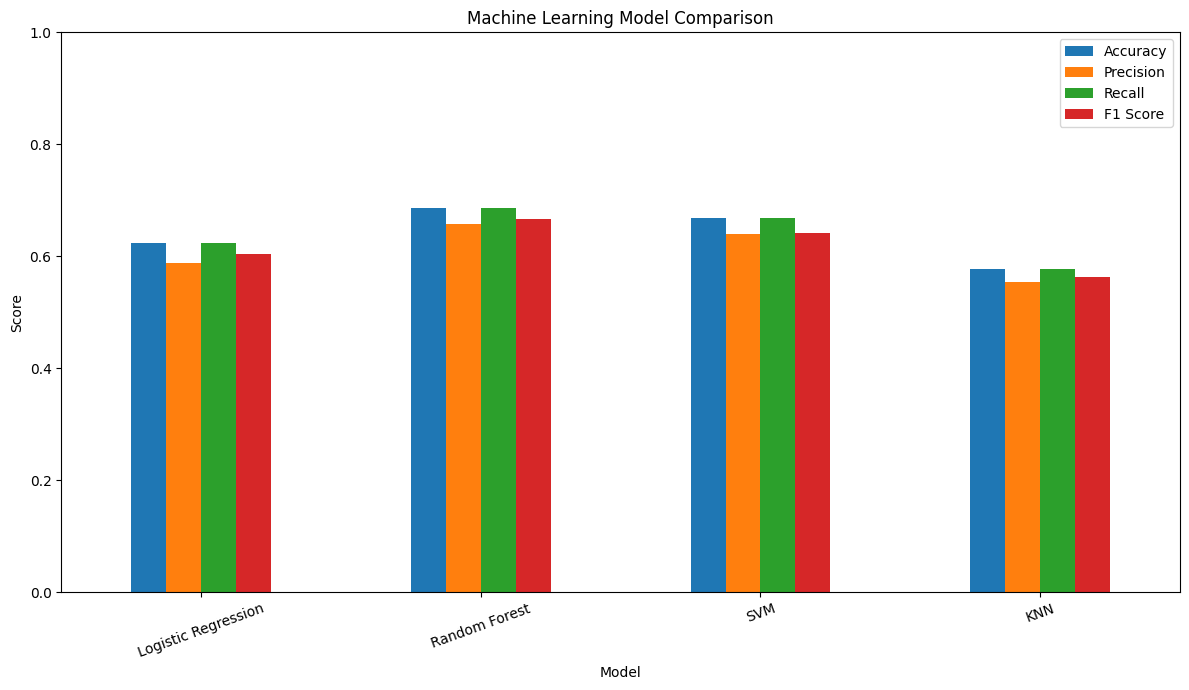

In [ ]:

results_plot = results_df.set_index('Model')

results_plot[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.legend()

plt.tight_layout()

plt.show()

# **Classification Reports**

In [ ]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print(
    classification_report(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print("=" * 60)
print("SVM")
print("=" * 60)

print(
    classification_report(
        y_test,
        svm_pred,
        zero_division=0
    )
)

print("=" * 60)
print("KNN")
print("=" * 60)

print(
    classification_report(
        y_test,
        knn_pred,
        zero_division=0
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.78      0.74        97
           6       0.59      0.63      0.61        92
           7       0.43      0.31      0.36        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.29      0.29      0.28       229
weighted avg       0.59      0.62      0.60       229

RANDOM FOREST
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.72      0.79      0.75        97
           6       0.63      0.71      0.67        92
           7       0.79      0.52      0.62        29
           8       0.00      0.00      0.00         3

    accuracy                           0.69

# **Automatically Find Best Model**

In [ ]:

best_model_row = results_df.loc[
    results_df['F1 Score'].idxmax()
]

print("Best Performing Model:")
print(best_model_row)

Best Performing Model:
Model        Random Forest
Accuracy           0.68559
Precision         0.658326
Recall             0.68559
F1 Score          0.666742
Name: 1, dtype: object


# **Confusion Matrix**

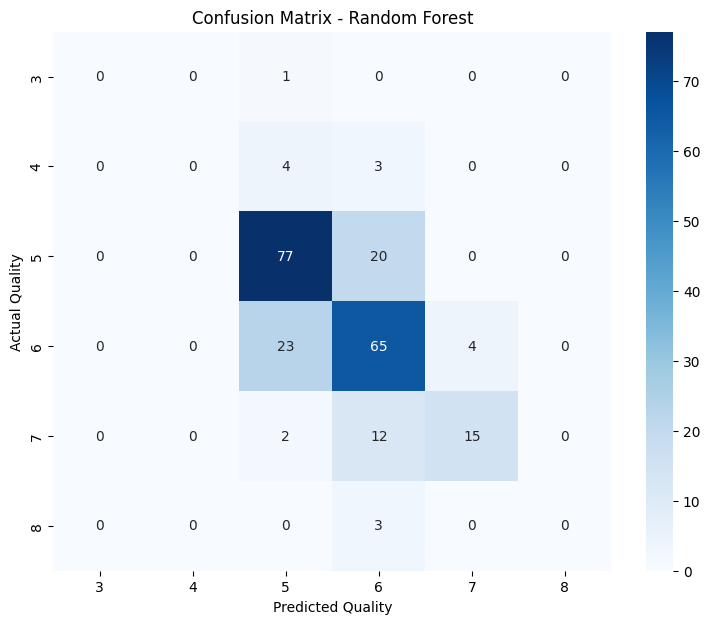

In [ ]:

model_predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "KNN": knn_pred
}

best_model_name = best_model_row['Model']

best_predictions = model_predictions[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=sorted(y.unique())
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()

# **Detailed Confusion Matrix Analysis**

In [ ]:
quality_labels = sorted(y.unique())

cm_df = pd.DataFrame(
    cm,
    index=quality_labels,
    columns=quality_labels
)

print("Confusion Matrix:")
display(cm_df)

print("\nMost common classification errors:")

errors = []

for actual in quality_labels:
    for predicted in quality_labels:

        if actual != predicted and cm_df.loc[actual, predicted] > 0:

            errors.append(
                (
                    cm_df.loc[actual, predicted],
                    actual,
                    predicted
                )
            )

errors = sorted(
    errors,
    reverse=True
)

for count, actual, predicted in errors[:10]:

    print(
        f"Actual {actual} → Predicted {predicted}: {count}"
    )

Confusion Matrix:


,3,4,5,6,7,8
3,0,0,1,0,0,0
4,0,0,4,3,0,0
5,0,0,77,20,0,0
6,0,0,23,65,4,0
7,0,0,2,12,15,0
8,0,0,0,3,0,0



Most common classification errors:
Actual 6 → Predicted 5: 23
Actual 5 → Predicted 6: 20
Actual 7 → Predicted 6: 12
Actual 6 → Predicted 7: 4
Actual 4 → Predicted 5: 4
Actual 8 → Predicted 6: 3
Actual 4 → Predicted 6: 3
Actual 7 → Predicted 5: 2
Actual 3 → Predicted 5: 1


# **Random Forest Feature Importance**

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
10,alcohol,0.138868
1,volatile acidity,0.120224
9,sulphates,0.119482
6,total sulfur dioxide,0.098885
4,chlorides,0.086927
8,pH,0.082321
7,density,0.079450
2,citric acid,0.078776
5,free sulfur dioxide,0.068899
0,fixed acidity,0.067457


# **Feature Importance Graph**

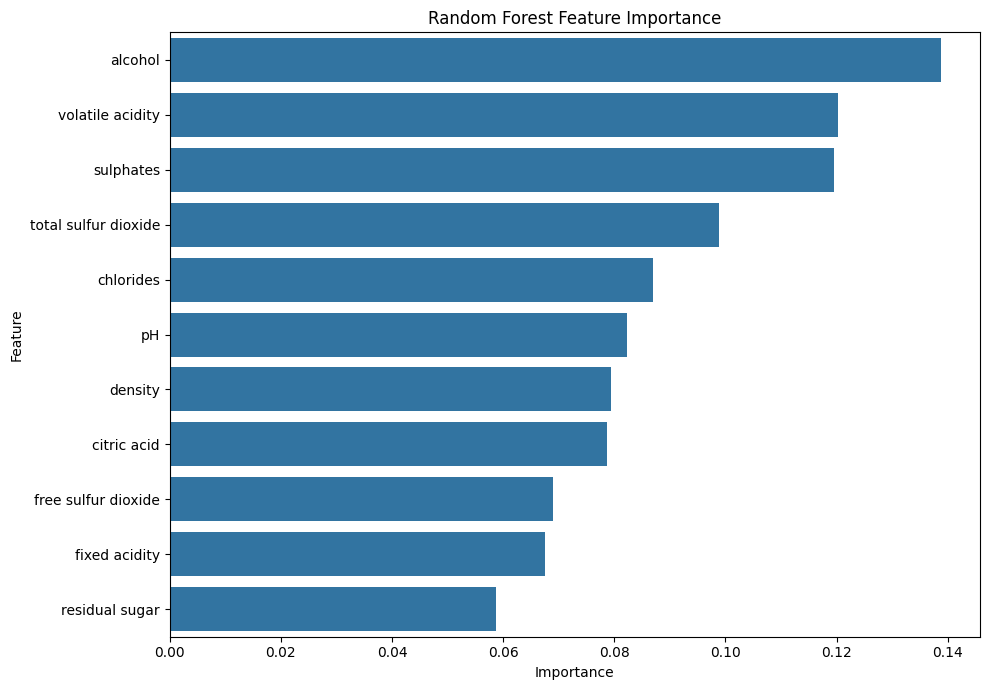

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# **Most Important Feature**

In [ ]:

most_important_feature = feature_importance.iloc[0]

print(
    "Most influential feature:",
    most_important_feature['Feature']
)

print(
    "Importance:",
    round(most_important_feature['Importance'], 4)
)

Most influential feature: alcohol
Importance: 0.1389


# **Hyperparameter Tuning**

In [ ]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed!")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Hyperparameter tuning completed!


# **Best Parameters**

In [ ]:

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.6407823363276877


# **Tuned Model Evaluation**

In [ ]:
tuned_rf = grid_search.best_estimator_

tuned_pred = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred,
    average='weighted',
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_pred,
    average='weighted',
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    average='weighted',
    zero_division=0
)

print("Tuned Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))

Tuned Random Forest Results
--------------------------------
Accuracy : 0.6812
Precision: 0.6537
Recall   : 0.6812
F1 Score : 0.6613


# **Original vs Tuned Random Forest**

In [ ]:

original_rf_metrics = evaluate_model(
    "Original Random Forest",
    y_test,
    rf_pred
)

tuned_rf_metrics = {
    'Model': 'Tuned Random Forest',
    'Accuracy': tuned_accuracy,
    'Precision': tuned_precision,
    'Recall': tuned_recall,
    'F1 Score': tuned_f1
}

comparison_rf = pd.DataFrame([
    original_rf_metrics,
    tuned_rf_metrics
])

display(comparison_rf)

,Model,Accuracy,Precision,Recall,F1 Score
0,Original Random Forest,0.685590,0.658326,0.685590,0.666742
1,Tuned Random Forest,0.681223,0.653685,0.681223,0.661284


# **Final Model Selection**

In [ ]:
if tuned_f1 >= original_rf_metrics['F1 Score']:

    final_model = tuned_rf
    final_model_name = "Tuned Random Forest"

else:

    final_model = rf_model
    final_model_name = "Original Random Forest"

print("Final selected model:", final_model_name)

Final selected model: Original Random Forest


# **Quality Category Function**

In [ ]:
def quality_category(quality):

    if quality in [3, 4]:
        return "Poor"

    elif quality == 5:
        return "Average"

    elif quality == 6:
        return "Good"

    elif quality in [7, 8]:
        return "Excellent"

    else:
        return "Unknown"

# **Prediction Function**

In [ ]:
def predict_wine_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):

    input_data = pd.DataFrame([{
        'fixed acidity': fixed_acidity,
        'volatile acidity': volatile_acidity,
        'citric acid': citric_acid,
        'residual sugar': residual_sugar,
        'chlorides': chlorides,
        'free sulfur dioxide': free_sulfur_dioxide,
        'total sulfur dioxide': total_sulfur_dioxide,
        'density': density,
        'pH': pH,
        'sulphates': sulphates,
        'alcohol': alcohol
    }])

    prediction = final_model.predict(input_data)[0]

    probabilities = final_model.predict_proba(input_data)[0]

    confidence = np.max(probabilities) * 100

    category = quality_category(prediction)

    print("=" * 50)
    print("       WINE QUALITY PREDICTION")
    print("=" * 50)

    print(f"Predicted Wine Quality : {prediction}")
    print(f"Quality Category       : {category}")
    print(f"Prediction Confidence  : {confidence:.2f}%")

    print("=" * 50)

    return prediction, category, confidence

# **Test Prediction**

In [ ]:

predict_wine_quality(
    fixed_acidity=7.4,
    volatile_acidity=0.70,
    citric_acid=0.00,
    residual_sugar=1.9,
    chlorides=0.076,
    free_sulfur_dioxide=11,
    total_sulfur_dioxide=34,
    density=0.9978,
    pH=3.51,
    sulphates=0.56,
    alcohol=9.4
)

       WINE QUALITY PREDICTION
Predicted Wine Quality : 5
Quality Category       : Average
Prediction Confidence  : 98.33%


(np.int64(5), 'Average', np.float64(98.33333333333333))

# **Interactive Wine Predictor**

In [ ]:
def interactive_wine_prediction():

    print("=" * 60)
    print("          WINE QUALITY PREDICTION SYSTEM")
    print("=" * 60)

    fixed_acidity = float(input("Fixed Acidity: "))
    volatile_acidity = float(input("Volatile Acidity: "))
    citric_acid = float(input("Citric Acid: "))
    residual_sugar = float(input("Residual Sugar: "))
    chlorides = float(input("Chlorides: "))
    free_sulfur_dioxide = float(input("Free Sulfur Dioxide: "))
    total_sulfur_dioxide = float(input("Total Sulfur Dioxide: "))
    density = float(input("Density: "))
    pH = float(input("pH: "))
    sulphates = float(input("Sulphates: "))
    alcohol = float(input("Alcohol: "))

    predict_wine_quality(
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    )

# **Final Confusion Matrix for Tuned Model**

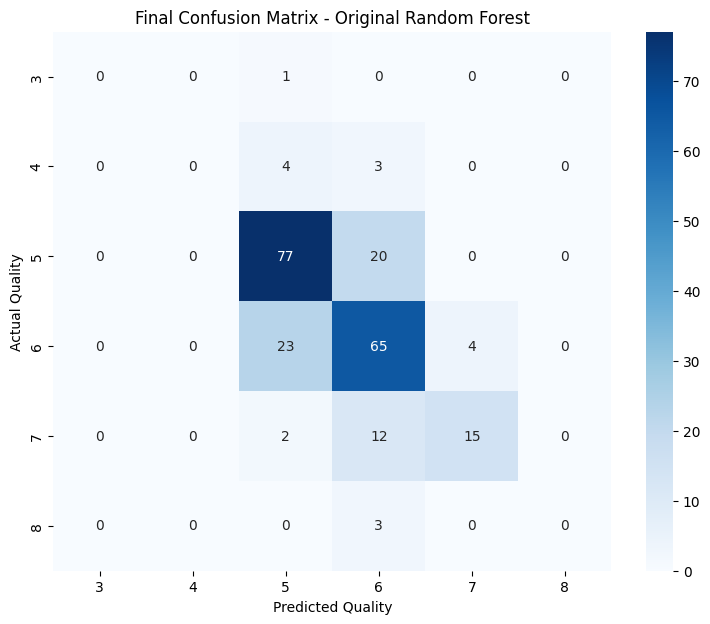

In [ ]:


final_pred = final_model.predict(X_test)

final_cm = confusion_matrix(
    y_test,
    final_pred,
    labels=sorted(y.unique())
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title(
    f"Final Confusion Matrix - {final_model_name}"
)

plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()

# **inal Classification Report**

In [ ]:
print(
    classification_report(
        y_test,
        final_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.72      0.79      0.75        97
           6       0.63      0.71      0.67        92
           7       0.79      0.52      0.62        29
           8       0.00      0.00      0.00         3

    accuracy                           0.69       229
   macro avg       0.36      0.34      0.34       229
weighted avg       0.66      0.69      0.67       229



# **Final Feature Importance**

In [ ]:

final_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
})

final_importance = final_importance.sort_values(
    by='Importance',
    ascending=False
)

display(final_importance)

,Feature,Importance
10,alcohol,0.138868
1,volatile acidity,0.120224
9,sulphates,0.119482
6,total sulfur dioxide,0.098885
4,chlorides,0.086927
8,pH,0.082321
7,density,0.079450
2,citric acid,0.078776
5,free sulfur dioxide,0.068899
0,fixed acidity,0.067457


# **Final Feature Importance Graph**

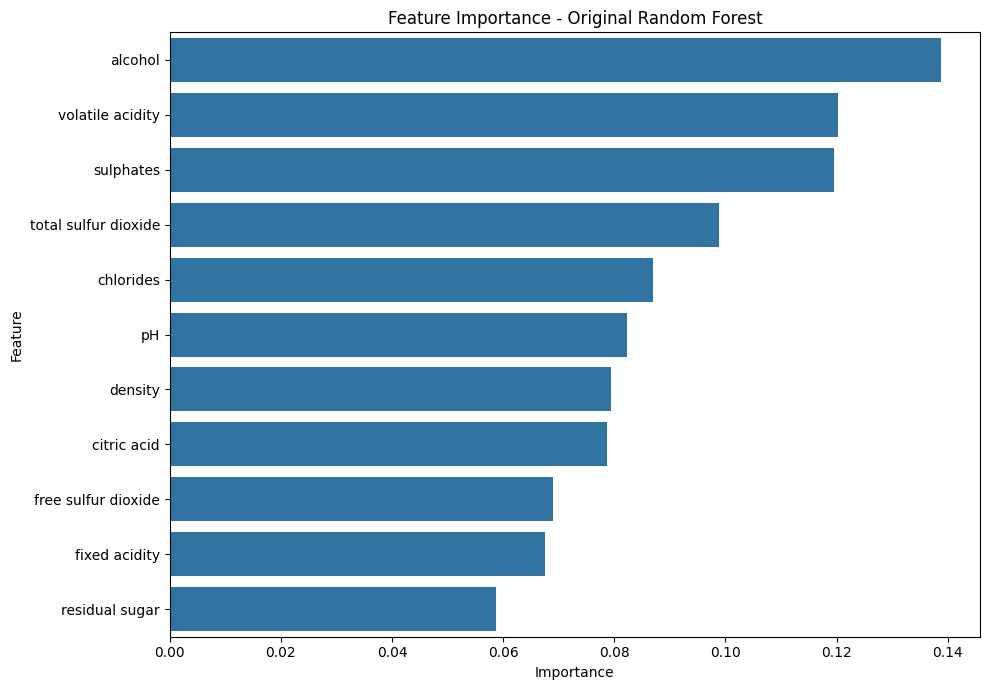

In [ ]:

plt.figure(figsize=(10, 7))

sns.barplot(
    data=final_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    f"Feature Importance - {final_model_name}"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# **Complete Final Results**

In [ ]:

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

final_precision = precision_score(
    y_test,
    final_pred,
    average='weighted',
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_pred,
    average='weighted',
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_pred,
    average='weighted',
    zero_division=0
)

print("=" * 60)
print("             FINAL PROJECT RESULTS")
print("=" * 60)

print(f"Final Model : {final_model_name}")
print(f"Accuracy    : {final_accuracy:.4f}")
print(f"Precision   : {final_precision:.4f}")
print(f"Recall      : {final_recall:.4f}")
print(f"F1 Score    : {final_f1:.4f}")

print("=" * 60)

print(
    "\nMost Important Feature:",
    final_importance.iloc[0]['Feature']
)

print(
    "Feature Importance:",
    round(final_importance.iloc[0]['Importance'], 4)
)

             FINAL PROJECT RESULTS
Final Model : Original Random Forest
Accuracy    : 0.6856
Precision   : 0.6583
Recall      : 0.6856
F1 Score    : 0.6667

Most Important Feature: alcohol
Feature Importance: 0.1389


# **Save Model**

In [ ]:
import joblib

joblib.dump(
    final_model,
    "wine_quality_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# **Download Model**

In [ ]:
from google.colab import files

files.download("wine_quality_model.pkl")

In [ ]:
interactive_wine_prediction()

          WINE QUALITY PREDICTION SYSTEM
Fixed Acidity: 7.4
Volatile Acidity: 0.70
Citric Acid: 0.00
Residual Sugar: 1.9
Chlorides: 0.076
Free Sulfur Dioxide: 11
Total Sulfur Dioxide: 34
Density: 0.9978
pH: 3.51
Sulphates: 0.56
Alcohol: 9.4
       WINE QUALITY PREDICTION
Predicted Wine Quality : 5
Quality Category       : Average
Prediction Confidence  : 98.33%
